# Part 2 Starter Notebook

This notebook loads an AIME 2024 dataset, runs a model on each problem, extracts an AIME-style final answer, and grades the outputs.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import re
import os

import pandas as pd
import torch
from datasets import load_dataset
# from transformers import AutoModelForCausalLM, AutoTokenizer

In [3]:
from google.colab import userdata

print("Token set" if userdata.get('HF_TOKEN') else "Token not set")

Token set


In [8]:
MODEL_NAME = "Qwen/Qwen3-4B"
# or allenai/Olmo-3-7B-Think
# MODEL_NAME = "allenai/Olmo-3-7B-Think"
DATASET_NAME = "OpenRLHF/aime-2024"
# MAX_NEW_TOKENS = 512
MAX_NEW_TOKENS = 8000

## Loading the model and the data

In [5]:
import os
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"

In [5]:
# device = "cuda" if torch.cuda.is_available() else "cpu"
# # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# hf_token = os.environ.get("HF_TOKEN")

# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=hf_token)
# model = AutoModelForCausalLM.from_pretrained(
#     MODEL_NAME,
#     dtype=torch.float16 if device == "cuda" else torch.float32,
#     token=hf_token
# )
# model.to(device)
# print(next(model.parameters()).device)

# if tokenizer.pad_token is None:
#     tokenizer.pad_token = tokenizer.eos_token
# tokenizer.padding_side = "left"

# dataset = load_dataset(DATASET_NAME, split="train", token=hf_token)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

cuda:0


In [6]:
print(tokenizer.padding_side)

left


## Evaluation helpers

In [9]:
def strip_thinking_trace(text):
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    text = re.sub(r"<\|begin_of_thought\|>.*?<\|end_of_thought\|>", "", text, flags=re.DOTALL)
    return text.strip()



def extract_answer(text: str, mode="exact_match") -> int | None:
    """Extract an AIME-style integer answer from a model completion."""
    answer_text = strip_thinking_trace(text)
    if not answer_text:
        if mode == "exact_match":
            return None
        else:
            answer_text = text  # fall back to full text


    # 1. Boxed LaTeX answer: \boxed{123}
    if mode == "exact_match":
        boxed = re.findall(r"\\boxed\{(\d+)\}", answer_text)
        if boxed:
            val = int(boxed[-1])
            return val
        else:
            return None

    elif mode == "flexible_extract":
        # 2. "The answer is N" or "answer: N" patterns
        patterns = [
            r"(?:the\s+)?answer\s+is\s+[:\s]*(\d+)",
            r"answer[:\s]+(\d+)",
            r"=\s*(\d+)\s*$",
            r"(?:therefore|thus|so),?\s+(\d+)\s*(?:\.|$)",
        ]
        for pattern in patterns:
            matches = re.findall(pattern, answer_text, re.IGNORECASE)
            if matches:
                val = int(matches[-1])
                return val

        # 3. Last integer in [0, 999] in the answer portion
        integers = re.findall(r"\b(\d{1,3})\b", answer_text)
        for candidate in reversed(integers):
            val = int(candidate)
            return val
        return None


## Scaling Experiments Helpers

For sequential scaling (token-by-token generation) --> need generation that:
- monitors token stream incrementally
- detects thought boundaries
- intervenes dynamically

For WAIT intervention:
- detect end-think token before budget reached
- override generation
- continue chain

For parallel scaling:
- requires stochastic sampling
- multiple completions
- currently only evaluate single completion --> need answer = [multiple samples] then aggregation logic

Plots needed:
- accuracy vs thinking tokens
- total tokens vs accuracy
- error bars
- exact vs flexible curves

## Inference

You can also explore using vLLM to speed up inference!

In [ ]:
ENABLE_THINKING = True  # Set False for no-thinking condition
ANSWER_MODE = "exact_match"

model.to(device)
model.eval()

records = []

for i, example in enumerate(dataset):
    messages = example["prompt"]
    gold_answer = int(example["label"])

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=ENABLE_THINKING,
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,    # False is greedy decoding, True would enable sampling probabilistically (for exploration)
            temperature=None,
            top_p=None,
            repetition_penalty=1.3
        )

    # Decode only the newly generated tokens
    generated_ids = output_ids[0][inputs["input_ids"].shape[1]:]
    model_output = tokenizer.decode(generated_ids, skip_special_tokens=True)

    think_len = None

    start = model_output.find("<think>")
    end = model_output.find("</think>")

    if start != -1:
        think_text = model_output[start + len("<think>"): end if end != -1 else None]
        think_tokens = tokenizer(think_text, add_special_tokens=False)["input_ids"]
        think_len = len(think_tokens)

    extracted = extract_answer(model_output, mode=ANSWER_MODE)
    if extracted is not None:
        correct = extracted == gold_answer
    else:
        correct = False

    records.append({
        "prompt": messages,
        "gold_answer": gold_answer,
        "model_output": model_output,
        "extracted_answer": extracted,
        "correct": correct,
        "think_len": think_len
    })

    print(f"[{i+1}/{len(dataset)}] gold={gold_answer} pred={extracted} correct={correct}")

results_df = pd.DataFrame(records)
results_df

Using vLLM

In [10]:
import os
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"

from vllm import LLM, SamplingParams
from datasets import load_dataset
from transformers import AutoTokenizer
import pandas as pd
import matplotlib.pyplot as plt

MODEL_NAME = MODEL_NAME
DATASET_NAME = DATASET_NAME

BATCH_SIZE = 8
MAX_NEW_TOKENS = MAX_NEW_TOKENS
ANSWER_MODE = "exact_match"

hf_token = os.environ.get("HF_TOKEN")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=hf_token)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

dataset = load_dataset(DATASET_NAME, split="train", token=hf_token)

llm = LLM(
    model=MODEL_NAME,
    # enforce_eager=True,
)

sampling_params = SamplingParams(
    max_tokens=MAX_NEW_TOKENS,
    temperature=0.0,
    top_p=1.0,
    repetition_penalty=1.3,
)

# storage
records_no_think = []
records_think = []
think_lengths = []

# no thinking evals
for i in range(0, len(dataset), BATCH_SIZE):
    batch = dataset.select(range(i, min(i + BATCH_SIZE, len(dataset))))

    prompts, labels = [], []

    for ex in batch:
        prompt = tokenizer.apply_chat_template(
            ex["prompt"],
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )
        prompts.append(prompt)
        labels.append(int(ex["label"]))

    outputs = llm.generate(prompts, sampling_params)

    for j, out in enumerate(outputs):
        pred = extract_answer(out.outputs[0].text, mode=ANSWER_MODE)
        gold = labels[j]

        records_no_think.append(pred == gold if pred is not None else False)

# thinking evals + length
for i in range(0, len(dataset), BATCH_SIZE):
    batch = dataset.select(range(i, min(i + BATCH_SIZE, len(dataset))))

    prompts, labels = [], []

    for ex in batch:
        prompt = tokenizer.apply_chat_template(
            ex["prompt"],
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=True,
        )
        prompts.append(prompt)
        labels.append(int(ex["label"]))

    outputs = llm.generate(prompts, sampling_params)

    for j, out in enumerate(outputs):
        text = out.outputs[0].text
        gold = labels[j]

        # extract thinking length
        think_len = None
        start = text.find("<think>")
        end = text.find("</think>")

        if start != -1:
            think_text = text[start + 8:end if end != -1 else None]
            if think_text:
                think_len = len(
                    tokenizer(think_text, add_special_tokens=False)["input_ids"]
                )
                think_lengths.append(think_len)

        # accuracy
        pred = extract_answer(text, mode=ANSWER_MODE)
        records_think.append(pred == gold if pred is not None else False)

INFO 04-30 02:26:09 [utils.py:233] non-default args: {'disable_log_stats': True, 'model': 'Qwen/Qwen3-4B'}
INFO 04-30 02:26:10 [model.py:555] Resolved architecture: Qwen3ForCausalLM
INFO 04-30 02:26:10 [model.py:1680] Using max model len 40960
INFO 04-30 02:26:10 [kernel.py:205] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'])


Rendering prompts:   0%|          | 0/8 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/8 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/8 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/8 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

Processed prompts:   0%|          | 0/8 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/8 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/8 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/6 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/6 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


Results
Accuracy (no thinking):  0.2
Accuracy (with thinking):  0.23333333333333334
Avg think length:  7161.766666666666


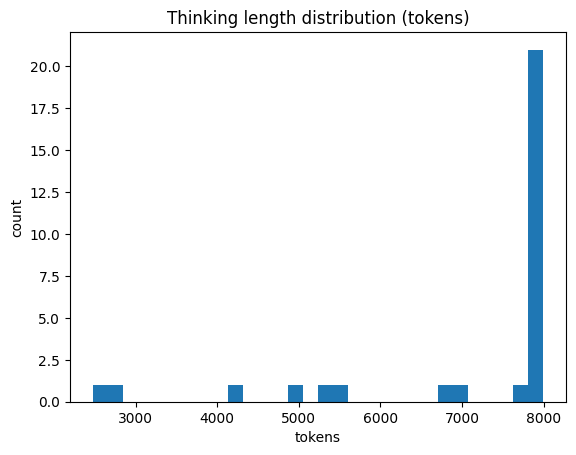

In [18]:

# results
acc_no_think = sum(records_no_think) / len(records_no_think)
acc_think = sum(records_think) / len(records_think)

print("\nResults")
print("Accuracy (no thinking): ", acc_no_think)
print("Accuracy (with thinking): ", acc_think)
print("Avg think length: ", sum(think_lengths)/len(think_lengths))

# histogram
plt.figure()
plt.hist(think_lengths, bins=30)
plt.title("Thinking length distribution (tokens)")
plt.xlabel("tokens")
plt.ylabel("count")
plt.show()

Run diagnostics

In [14]:
# ENABLE_THINKING = True  # Set False for no-thinking condition
# ANSWER_MODE = "exact_match"

model.to(device)
model.eval()

BATCH_SIZE = 4
records = []

example = dataset[0]
prompt = tokenizer.apply_chat_template(
    example["prompt"], tokenize=False,
    add_generation_prompt=True, enable_thinking=True,
)
inputs = tokenizer(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=8000, do_sample=False,
                         temperature=0.6, top_p=0.95, repetition_penalty=1.5)

text = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
print(repr(text[:500]))   # first 500 chars
print("...")
print(repr(text[-200:]))  # last 200 chars — did </think> appear?
print(f"\nTotal tokens generated: {len(out[0]) - inputs['input_ids'].shape[1]}")
print(f"Contains </think>: {'</think>' in text}")

"<think>\nOkay, so I need to find the maximum value of this expression: (75 + 117i) times z plus (96 + 144i)/z where |z| = 4. Hmm, let me think about how to approach this. \n\nFirst off, since we're dealing with complex numbers and their magnitudes are given as fixed at 4 for all such expressions involving 'z', maybe there's some way to use properties related to modulus or perhaps write it in terms that can be maximized using calculus? Or even trigonometric substitution?\n\nLet me recall that if |z| ="
...
'iew\n\nYou are tasked with finding the **greatest possible real part**, among all choices of nonzero complex numbers `z` satisfying `$|\\mathbf{z}| = 4$, of the mathematical expression:\n\n$$\nQ(\\texttt{\\em'

Total tokens generated: 8000
Contains </think>: True


In [ ]:
results_df.to_csv("results/greedy_with_think.csv", index=False)

In [ ]:
results_df["correct"].mean()